# Network modeling

model the network and derive travel time matrix

In [37]:
import networkx as nx
import numpy as np
import pandas as pd

# Create a directed graph
G = nx.DiGraph()

# Add edges with weights based on the image
edges = [
    (0, 1, 22), (0, 2, 20),
    (1, 3, 20), (1, 4, 20), (1, 5, 22),
    (2, 5, 20), (2, 6, 20),
    (3, 7, 20),
    (4, 7, 22), (4, 8, 20),
    (5, 8, 20), (5, 9, 22),
    (6, 9, 20),
    (7, 10, 20), (7, 11, 24),
    (8, 11, 20),
    (9, 11, 20),
    (10, 12, 10),
    (11, 12, 10)
]
G.add_weighted_edges_from(edges)

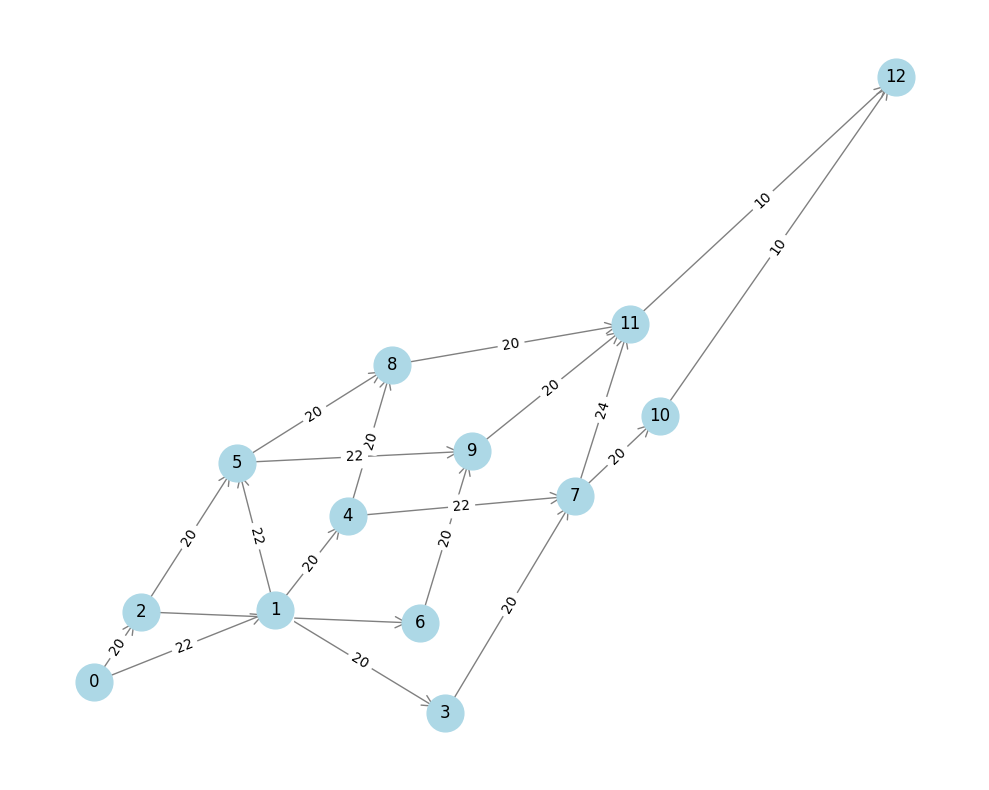

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G,seed=42)
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.axis('off')
plt.tight_layout()
plt.show()


In [41]:
22+20+20+20+10

92

In [39]:
# Compute distance matrix using Floyd-Warshall algorithm
distance_matrix = nx.floyd_warshall_numpy(G, weight='weight')

# Convert to DataFrame for readability
nodes = list(G.nodes())
df = pd.DataFrame(distance_matrix, index=nodes, columns=nodes)

print(df)

     0     1     2     3     4     5     6     7     8     9     10    11  \
0   0.0  22.0  20.0  42.0  42.0  40.0  40.0  62.0  60.0  60.0  82.0  80.0   
1   inf   0.0   inf  20.0  20.0  22.0   inf  40.0  40.0  44.0  60.0  60.0   
2   inf   inf   0.0   inf   inf  20.0  20.0   inf  40.0  40.0   inf  60.0   
3   inf   inf   inf   0.0   inf   inf   inf  20.0   inf   inf  40.0  44.0   
4   inf   inf   inf   inf   0.0   inf   inf  22.0  20.0   inf  42.0  40.0   
5   inf   inf   inf   inf   inf   0.0   inf   inf  20.0  22.0   inf  40.0   
6   inf   inf   inf   inf   inf   inf   0.0   inf   inf  20.0   inf  40.0   
7   inf   inf   inf   inf   inf   inf   inf   0.0   inf   inf  20.0  24.0   
8   inf   inf   inf   inf   inf   inf   inf   inf   0.0   inf   inf  20.0   
9   inf   inf   inf   inf   inf   inf   inf   inf   inf   0.0   inf  20.0   
10  inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   0.0   inf   
11  inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   0.0   

In [40]:
nx.shortest_path(G, 0, 12)

[0, 1, 3, 7, 10, 12]

In [42]:
sp = dict(nx.all_pairs_shortest_path(G))

In [44]:
sp[0]

{0: [0],
 1: [0, 1],
 2: [0, 2],
 3: [0, 1, 3],
 4: [0, 1, 4],
 5: [0, 1, 5],
 6: [0, 2, 6],
 7: [0, 1, 3, 7],
 8: [0, 1, 4, 8],
 9: [0, 1, 5, 9],
 10: [0, 1, 3, 7, 10],
 11: [0, 1, 3, 7, 11],
 12: [0, 1, 3, 7, 10, 12]}

In [54]:
sp[0][12]

[0, 1, 3, 7, 10, 12]

In [60]:
total_weight = sum(G.edges[node, sp[0][12][i+1]]['weight'] for i, node in enumerate(sp[0][12][:-1]))
print("Total weight of all edges:", total_weight)

Total weight of all edges: 92
